In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Dataset

In [3]:
data = pd.read_csv("EcoPackAi_dataset.csv")
data.head()

,Material ID,Packaging Type,Material Type,Suitable Product Categories,Recommended Packaging Use Cases,Supplier Region,Recyclability (%),Recyclability Category,Recycled Content (%),Reusability (%),...,CO2 Emission per kg (estimated),Waste Reduction Impact (%),Sustainability Target Progress (%),Load Handling Score,Moisture Resistance Score,Thermal Resistance Score,Cost per Unit (USD),Annual Usage (units),Total Material Weight (tons),Supplier Sustainability Compliance (%)
0,MAT_0001,Cardboard Boxes,Cardboard,"E-commerce, Food & Beverage, Consumer Goods, A...",Last-mile delivery and primary e-commerce pack...,EMEA,98,High,79.0,49.0,...,0.54,61.0,88.0,6.0,5.0,4.0,2.24,101260.0,790.0,85.0
1,MAT_0002,Protective Fillers (Paper/Biodegradable),Paper/Bio-Based,"Fragile Items, Cosmetics, Pharmaceuticals, Int...",Void-fill and cushioning for fragile products,APAC,100,High,93.0,31.0,...,0.32,68.0,98.0,3.0,3.0,3.0,1.82,73961.0,545.0,88.0
2,MAT_0003,Steel Racks & Containers,Steel,"Heavy Industrial Components, High-Security Goods","Secure, high-load international shipping and l...",AMERICAS,87,High,78.0,100.0,...,3.25,85.0,79.0,8.0,9.0,9.0,25.00,14649.0,4979.0,88.0
3,MAT_0004,Protective Fillers (Paper/Biodegradable),Paper/Bio-Based,"Fragile Items, Cosmetics, Pharmaceuticals, Int...",Void-fill and cushioning for fragile products,ROW,100,High,89.0,31.0,...,0.31,69.0,87.0,1.0,1.0,4.0,2.43,75036.0,656.0,81.0
4,MAT_0005,Protective Fillers (Paper/Biodegradable),Paper/Bio-Based,"Fragile Items, Cosmetics, Pharmaceuticals, Int...",Void-fill and cushioning for fragile products,LATAM,100,High,92.0,28.0,...,0.31,61.0,89.0,3.0,2.0,3.0,1.69,69209.0,549.0,81.0


## 2. Explore Structure

In [10]:
data.shape

(404, 23)

In [11]:
data.columns

Index(['Material ID', 'Packaging Type', 'Material Type',
       'Suitable Product Categories', 'Recommended Packaging Use Cases',
       'Supplier Region', 'Recyclability (%)', 'Recyclability Category',
       'Recycled Content (%)', 'Reusability (%)', 'Biodegradation Time (days)',
       'End-of-Life Disposal (%)', 'Carbon Footprint (kg CO2/unit)',
       'CO2 Emission per kg (estimated)', 'Waste Reduction Impact (%)',
       'Sustainability Target Progress (%)', 'Load Handling Score',
       'Moisture Resistance Score', 'Thermal Resistance Score',
       'Cost per Unit (USD)', 'Annual Usage (units)',
       'Total Material Weight (tons)',
       'Supplier Sustainability Compliance (%)'],
      dtype='object')

In [12]:
data.dtypes

Material ID                                object
Packaging Type                             object
Material Type                              object
Suitable Product Categories                object
Recommended Packaging Use Cases            object
Supplier Region                            object
Recyclability (%)                           int64
Recyclability Category                     object
Recycled Content (%)                      float64
Reusability (%)                           float64
Biodegradation Time (days)                float64
End-of-Life Disposal (%)                  float64
Carbon Footprint (kg CO2/unit)            float64
CO2 Emission per kg (estimated)           float64
Waste Reduction Impact (%)                float64
Sustainability Target Progress (%)        float64
Load Handling Score                       float64
Moisture Resistance Score                 float64
Thermal Resistance Score                  float64
Cost per Unit (USD)                       float64


## 3. Summary Statistics

In [13]:
data.describe

<bound method NDFrame.describe of     Material ID                            Packaging Type    Material Type  \
0      MAT_0001                           Cardboard Boxes        Cardboard   
1      MAT_0002  Protective Fillers (Paper/Biodegradable)  Paper/Bio-Based   
2      MAT_0003                  Steel Racks & Containers            Steel   
3      MAT_0004  Protective Fillers (Paper/Biodegradable)  Paper/Bio-Based   
4      MAT_0005  Protective Fillers (Paper/Biodegradable)  Paper/Bio-Based   
..          ...                                       ...              ...   
399    MAT_0400                   Plastic Totes & Pallets          Plastic   
400    MAT_0401                           Cardboard Boxes        Cardboard   
401    MAT_0402                   Plastic Totes & Pallets          Plastic   
402    MAT_0403                           Cardboard Boxes        Cardboard   
403    MAT_0404                   Plastic Totes & Pallets          Plastic   

                           Su

In [14]:
data.nunique()

Material ID                               404
Packaging Type                              6
Material Type                               4
Suitable Product Categories                 6
Recommended Packaging Use Cases             6
Supplier Region                             6
Recyclability (%)                          34
Recyclability Category                      2
Recycled Content (%)                       57
Reusability (%)                            46
Biodegradation Time (days)                160
End-of-Life Disposal (%)                   15
Carbon Footprint (kg CO2/unit)             99
CO2 Emission per kg (estimated)            63
Waste Reduction Impact (%)                 47
Sustainability Target Progress (%)         38
Load Handling Score                        10
Moisture Resistance Score                  10
Thermal Resistance Score                    9
Cost per Unit (USD)                       144
Annual Usage (units)                      163
Total Material Weight (tons)      

In [15]:
data.value_counts()

Material ID  Packaging Type                            Material Type    Suitable Product Categories                                               Recommended Packaging Use Cases                                 Supplier Region  Recyclability (%)  Recyclability Category  Recycled Content (%)  Reusability (%)  Biodegradation Time (days)  End-of-Life Disposal (%)  Carbon Footprint (kg CO2/unit)  CO2 Emission per kg (estimated)  Waste Reduction Impact (%)  Sustainability Target Progress (%)  Load Handling Score  Moisture Resistance Score  Thermal Resistance Score  Cost per Unit (USD)  Annual Usage (units)  Total Material Weight (tons)  Supplier Sustainability Compliance (%)
MAT_0001     Cardboard Boxes                           Cardboard        E-commerce, Food & Beverage, Consumer Goods, Apparel                      Last-mile delivery and primary e-commerce packaging             EMEA             98                 High                    79.0                  49.0             188.0        

<function matplotlib.pyplot.show(close=None, block=None)>

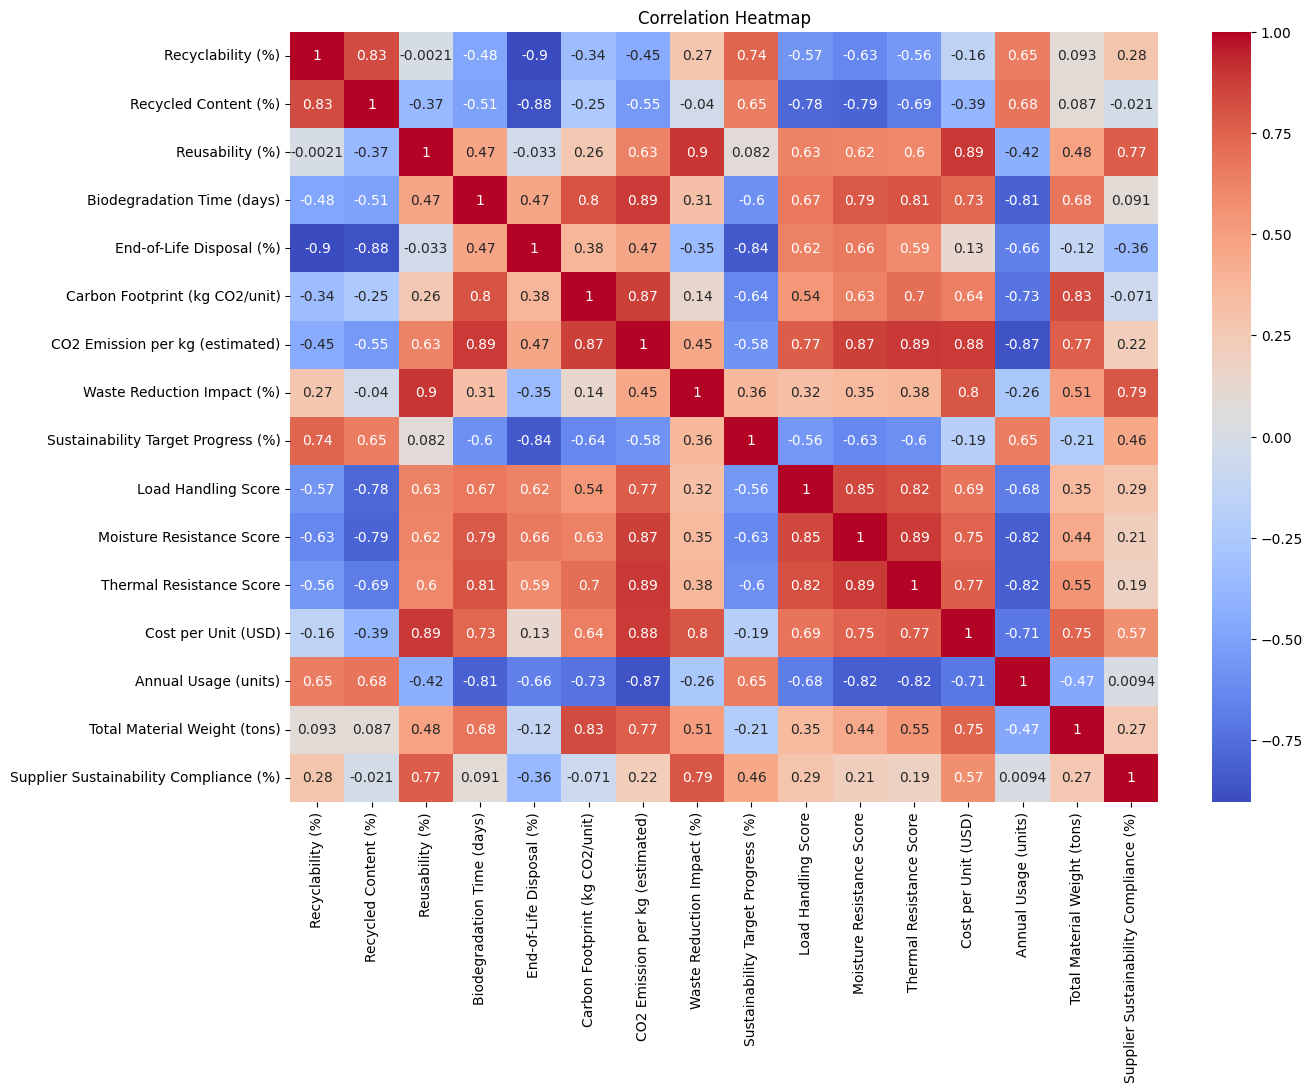

In [21]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show

## 4. Missing / Bad Data Analysis

In [31]:
missing_values = data.isna().sum()
missing_values.to_csv("missing_value_table.csv")
missing_values


Material ID                               0
Packaging Type                            0
Material Type                             0
Suitable Product Categories               0
Recommended Packaging Use Cases           0
Supplier Region                           0
Recyclability (%)                         0
Recyclability Category                    0
Recycled Content (%)                      1
Reusability (%)                           1
Biodegradation Time (days)                1
End-of-Life Disposal (%)                  1
Carbon Footprint (kg CO2/unit)            1
CO2 Emission per kg (estimated)           1
Waste Reduction Impact (%)                1
Sustainability Target Progress (%)        1
Load Handling Score                       1
Moisture Resistance Score                 1
Thermal Resistance Score                  1
Cost per Unit (USD)                       1
Annual Usage (units)                      1
Total Material Weight (tons)              1
Supplier Sustainability Complian

In [25]:
data.duplicated().sum()

np.int64(0)

In [26]:
num_cols = data.select_dtypes(include=['float64','int64']).columns

outliers = {}
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers[col] = data[(data[col] < lower) | (data[col] > upper)][col].count()

outliers

{'Recyclability (%)': np.int64(12),
 'Recycled Content (%)': np.int64(0),
 'Reusability (%)': np.int64(0),
 'Biodegradation Time (days)': np.int64(12),
 'End-of-Life Disposal (%)': np.int64(30),
 'Carbon Footprint (kg CO2/unit)': np.int64(59),
 'CO2 Emission per kg (estimated)': np.int64(18),
 'Waste Reduction Impact (%)': np.int64(13),
 'Sustainability Target Progress (%)': np.int64(30),
 'Load Handling Score': np.int64(0),
 'Moisture Resistance Score': np.int64(0),
 'Thermal Resistance Score': np.int64(0),
 'Cost per Unit (USD)': np.int64(0),
 'Annual Usage (units)': np.int64(0),
 'Total Material Weight (tons)': np.int64(46),
 'Supplier Sustainability Compliance (%)': np.int64(30)}

In [27]:
invalid_range = data[
    (data["Recyclability (%)"] > 100) | (data["Recyclability (%)"] < 0) |
    (data["Reusability (%)"] > 100) | (data["Reusability (%)"] < 0) |
    (data["Cost per Unit (USD)"] < 0) |
    (data["Carbon Footprint (kg CO2/unit)"] < 0)
]
invalid_range


,Material ID,Packaging Type,Material Type,Suitable Product Categories,Recommended Packaging Use Cases,Supplier Region,Recyclability (%),Recyclability Category,Recycled Content (%),Reusability (%),...,CO2 Emission per kg (estimated),Waste Reduction Impact (%),Sustainability Target Progress (%),Load Handling Score,Moisture Resistance Score,Thermal Resistance Score,Cost per Unit (USD),Annual Usage (units),Total Material Weight (tons),Supplier Sustainability Compliance (%)


## 5. Visualization

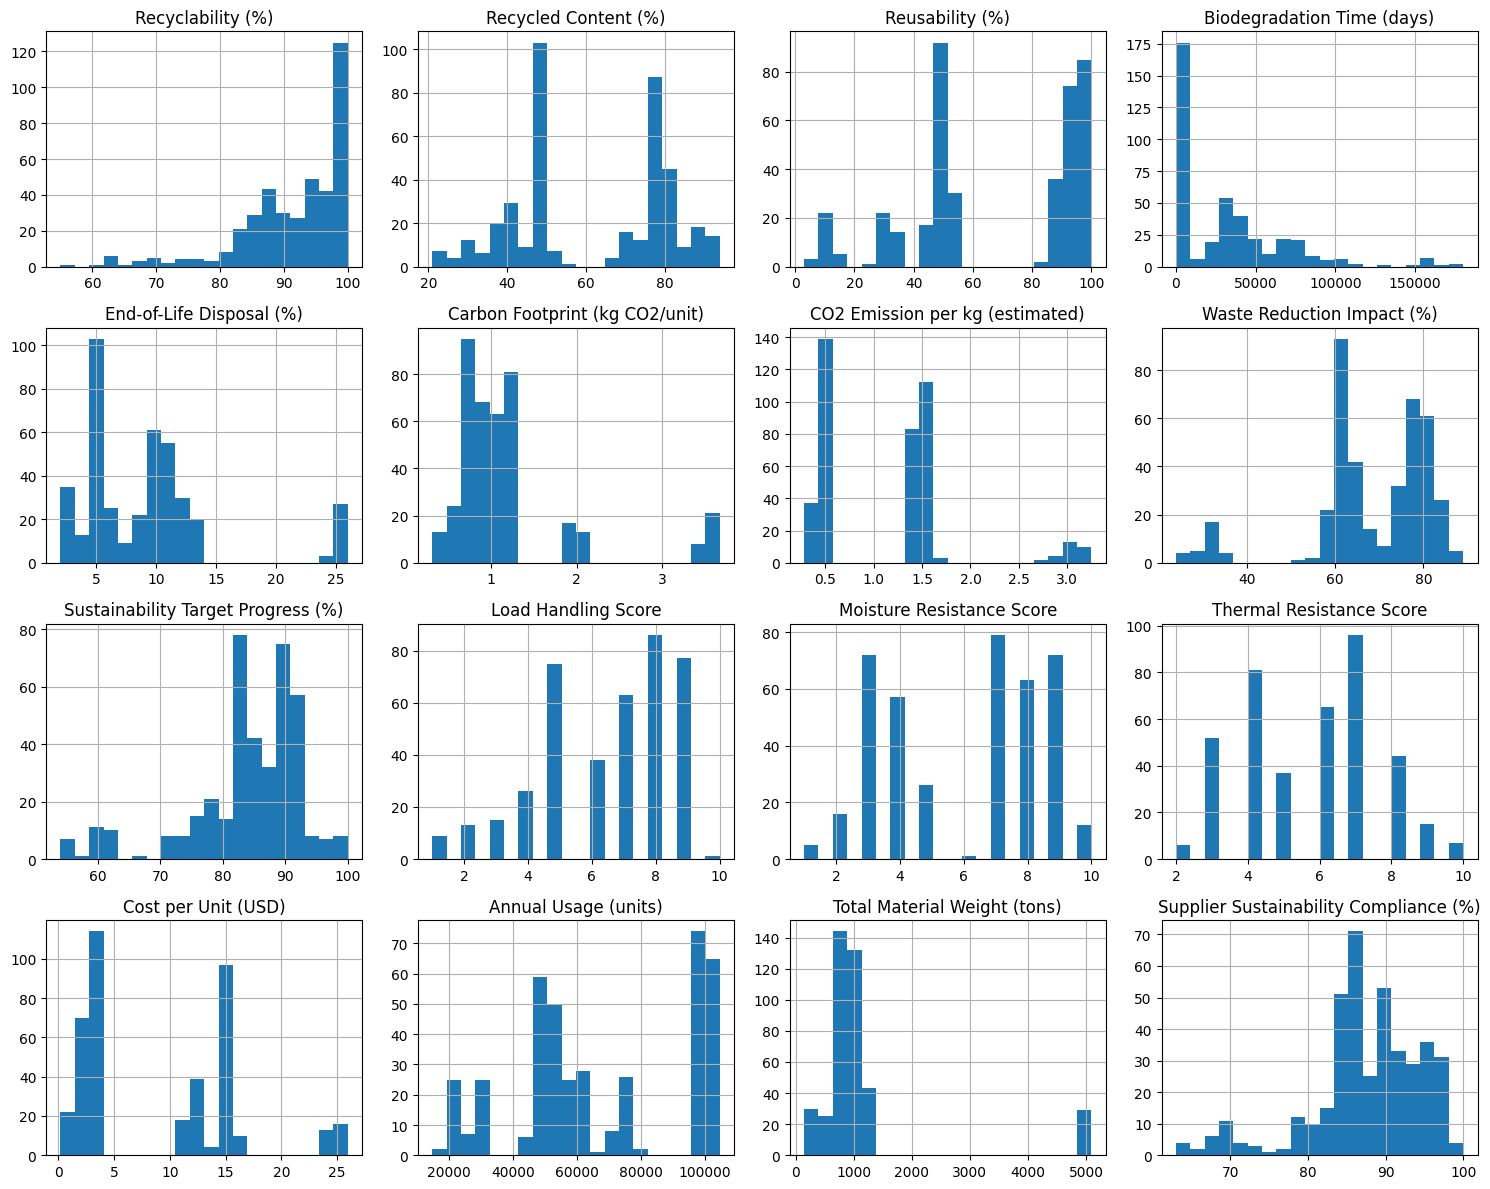

In [28]:
data.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()


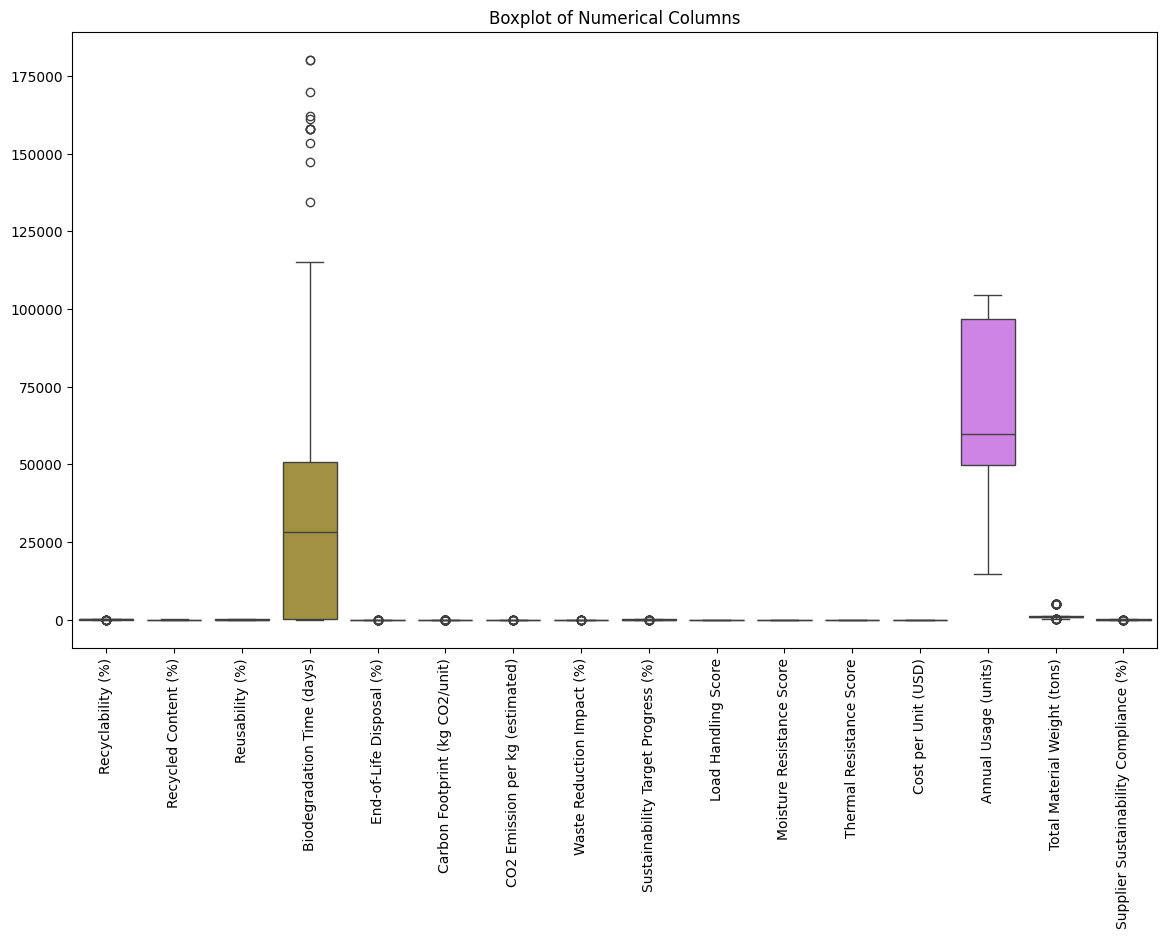

In [ ]:
plt.figure(figsize=(14,8))
sns.boxplot(data=data.select_dtypes(include=['float64','int64']))
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Columns")
plt.show()

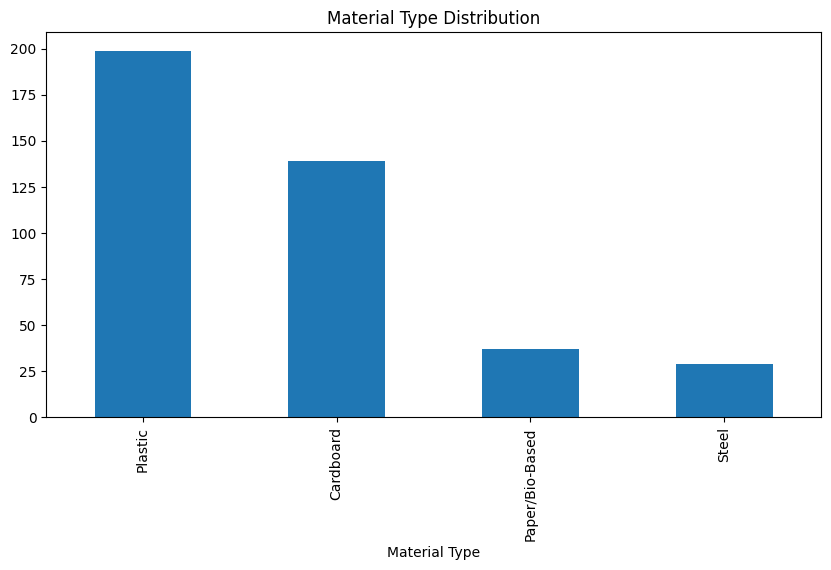

In [30]:
plt.figure(figsize=(10,5))
data["Material Type"].value_counts().plot(kind="bar")
plt.title("Material Type Distribution")
plt.show()


## 6. Handle Missing Values

In [8]:
from sklearn.impute import SimpleImputer
import pandas as pd

data = pd.read_csv("EcoPackAi_dataset.csv")

# Select numeric columns
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Median imputer
imputer = SimpleImputer(strategy="median")

data[numeric_cols] = imputer.fit_transform(data[numeric_cols])

# Save cleaned dataset
data.to_csv("../../data/processed/cleaned_data.csv", index=False)


## 7. Encode Categorical Features & Normalize Numeric Values.

In [14]:
categorical_cols = [
    "Packaging Type",
    "Material Type",
    "Recyclability Category",
    "Supplier Region",
    "Suitable Product Categories",
    "Recommended Packaging Use Cases"
]


In [12]:
# import pandas as pd

data = pd.read_csv("../../data/processed/cleaned_data.csv")
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()


In [ ]:
# One-Hot Encode Categorical Columns
from sklearn.preprocessing import OneHotEncoder

# Create OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit & transform
encoded_cats = ohe.fit_transform(data[categorical_cols])

# Convert to DataFrame
encoded_cat_df = pd.DataFrame(encoded_cats, columns=ohe.get_feature_names_out(categorical_cols))

# Reset index to match
encoded_cat_df.index = data.index


In [16]:
# Normalize Numeric Columns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_nums = scaler.fit_transform(data[numeric_cols])
scaled_num_df = pd.DataFrame(scaled_nums, columns=numeric_cols, index=data.index)


In [18]:
# Keep Material ID as is
final_df = pd.concat([data[['Material ID']], scaled_num_df, encoded_cat_df], axis=1)

# Save final ML-ready dataset
final_df.to_csv("../../data/model_ready/materials_final_encoded.csv", index=False)


In [21]:
import joblib

# Save One-Hot Encoder
joblib.dump(ohe, "../../models/encoders/ohe_encoder.pkl")

# Save Scaler
joblib.dump(scaler, "../../models/scalers/numeric_scaler.pkl")


['../../models/scalers/numeric_scaler.pkl']

## Generate Engineered Dataset

In [2]:
import pandas as pd

df = pd.read_csv("../../data/model_ready/materials_final_encoded.csv")  

df["cii"] = (
    (1 - df["CO2 Emission per kg (estimated)"]) * 0.4 +
    (1 - df["Biodegradation Time (days)"]) * 0.3 +
    df["Recyclability (%)"] * 0.3
) * 100

df["cei"] = (
    (1 - df["Cost per Unit (USD)"]) * 0.5 +
    df["Reusability (%)"] * 0.2 +
    df["Recyclability (%)"] * 0.3
) * 100

df["mss"] = (
    df["Load Handling Score"] * 0.3 +
    df["Moisture Resistance Score"] * 0.3 +
    df["Thermal Resistance Score"] * 0.2 +
    df["Reusability (%)"] * 0.2
) * 100

df["cii"] = df["cii"].clip(0, 100)
df["cei"] = df["cei"].clip(0, 100)
df["mss"] = df["mss"].clip(0, 100)

df.to_csv("../../data/engineered/engineered_dataset.csv", index=False)

print("✅ Engineered dataset saved successfully!")


✅ Engineered dataset saved successfully!


## Save Parquet files

In [3]:
import pandas as pd

# Load datasets
cleaned_df = pd.read_csv("../../data/processed/cleaned_data.csv")
engineered_df = pd.read_csv("../../data/engineered/engineered_dataset.csv")
model_ready_df = pd.read_csv("../../data/model_ready/materials_final_encoded.csv")


# Save as parquet
cleaned_df.to_parquet(
    "../../data/final/materials_cleaned.parquet",
    engine="pyarrow",
    index=False
)

engineered_df.to_parquet(
    "../../data/final/materials_engineered.parquet",
    engine="pyarrow",
    index=False
)

model_ready_df.to_parquet(
    "../../data/final/materials_model_ready.parquet",
    engine="pyarrow",
    index=False
)

print("✅ All Parquet files saved successfully")



✅ All Parquet files saved successfully


In [5]:
import pandas as pd

df = pd.read_parquet("../../data/final/materials_model_ready.parquet")

lines = []
lines.append("# 📦 EcoPackAI – Data Dictionary v2\n")
lines.append("## Dataset Summary\n")
lines.append(f"- **Rows:** {df.shape[0]}")
lines.append(f"- **Columns:** {df.shape[1]}")
lines.append("- **Status:** Production Ready\n\n")

lines.append("## Column-Level Details\n")

for col in df.columns:
    lines.append(f"### `{col}`")
    lines.append(f"- **Data Type:** {df[col].dtype}")
    lines.append(f"- **Nullable:** {'Yes' if df[col].isnull().any() else 'No'}")
    lines.append(f"- **Derived:** {'Yes' if col in ['cii','cei','mss','recommendation_score'] else 'No'}")
    lines.append(f"- **Used in ML:** Yes")
    lines.append(f"- **Example Value:** `{df[col].iloc[0]}`\n")

with open("../../docs/data_dictionary_v2.md", "w", encoding="utf-8") as f:
    f.write("\n".join(lines))


print("✅ data_dictionary_v2.md created")


✅ data_dictionary_v2.md created


In [7]:
records = []

for col in df.columns:
    records.append({
        "Column Name": col,
        "Data Type": str(df[col].dtype),
        "Description": "Refer project documentation",
        "Nullable": "Yes" if df[col].isnull().any() else "No",
        "Derived": "Yes" if col in ['cii','cei','mss','recommendation_score'] else "No",
        "Used in ML": "Yes",
        "Example Value": df[col].iloc[0]
    })

dict_df = pd.DataFrame(records)
dict_df.to_excel("../../docs/data_dictionary_v2.xlsx", index=False)

print("✅ data_dictionary_v2.xlsx created")


✅ data_dictionary_v2.xlsx created


In [8]:
import shutil

# Raw archive
shutil.copy(
    "../../data/raw/EcoPackAI_dataset.csv",
    "../../archive/raw_data_v1.csv"
)

# Cleaned archive
shutil.copy(
    "../../data/final/materials_cleaned.parquet",
    "../../archive/cleaned_data_v1.parquet"
)

# Old dictionary archive
shutil.copy(
    "../../docs/data_dictionary_v1.md",
    "../../archive/data_dictionary_v1.md"
)

print("✅ Archival completed")


✅ Archival completed
